In [1]:
import numpy as np
import pandas as pd
from sklearn.calibration import LabelEncoder
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# Load the dataset
data = pd.read_csv('PaySim\\PS_20174392719_1491204439457_log.csv')  # Replace with actual file path

# Label Encoding for high-cardinality 'nameOrig' and 'nameDest'
le_nameOrig = LabelEncoder()
le_nameDest = LabelEncoder()
le_type = LabelEncoder()
data['nameOrig_encoded'] = le_nameOrig.fit_transform(data['nameOrig'])
data['nameDest_encoded'] = le_nameDest.fit_transform(data['nameDest'])
data['type_encoded'] = le_nameDest.fit_transform(data['type'])

# Drop the original columns to save memory
data.drop(columns=['nameOrig', 'nameDest', 'type'], inplace=True)
data.drop(columns=['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'], inplace=True)

# List of numerical features to scale
numerical_features = ['step', 'amount']

# Scale numerical features to ensure standardized values
scaler = StandardScaler()
data[numerical_features] = scaler.fit_transform(data[numerical_features])

# Check the mean (~0) and standard deviation (~1) of the scaled features
scaled_stats = data[numerical_features].agg(['mean', 'std'])
print(scaled_stats)
print()

# Step 4: Data balancing using SMOTE for the target variable 'isFraud'
X = data.drop(columns=['isFraud'])  # Features
y = data['isFraud']                # Target 

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("Original shape:", X.shape, y.shape)
print("Original class distribution:", np.bincount(y))
print("Balanced shape:", X_balanced.shape, y_balanced.shape)
print("Balanced class distribution:", np.bincount(y_balanced))
print()

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# Check the shape of each split
print("Training set (features):", X_train.shape)
print("Training set (target):", y_train.shape)
print("Test set (features):", X_test.shape)
print("Test set (target):", y_test.shape)
print()

# Check the distribution of the target (fraud vs. non-fraud)
print("Training set fraud distribution:")
print(y_train.value_counts())
print()

print("Test set fraud distribution:")
print(y_test.value_counts())


              step        amount
mean -1.909724e-16 -4.946736e-17
std   1.000000e+00  1.000000e+00

Original shape: (6362620, 6) (6362620,)
Original class distribution: [6354407    8213]
Balanced shape: (12708814, 6) (12708814,)
Balanced class distribution: [6354407 6354407]

Training set (features): (10167051, 6)
Training set (target): (10167051,)
Test set (features): (2541763, 6)
Test set (target): (2541763,)

Training set fraud distribution:
isFraud
0    5083570
1    5083481
Name: count, dtype: int64

Test set fraud distribution:
isFraud
1    1270926
0    1270837
Name: count, dtype: int64


In [2]:
# Train XGBoost model
xgb_model = xgb.XGBClassifier(scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]), 
                               use_label_encoder=False, 
                               eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

Cross-Validation

In [3]:
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring="roc_auc")
print("Cross-Validated AUC Scores:", cv_auc)
print("Mean AUC:", cv_auc.mean())

c:\Users\sonia\Desktop\project\.venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:32:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\sonia\Desktop\project\.venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:32:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\sonia\Desktop\project\.venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:33:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\User

Cross-Validated AUC Scores: [0.9858682  0.98572428 0.98598947 0.98579168 0.98584819]
Mean AUC: 0.9858443630245441


See if model overfits.

In [4]:
# Evaluate on training data
y_train_pred = xgb_model.predict(X_train)
y_train_pred_prob = xgb_model.predict_proba(X_train)[:, 1]

train_auc = roc_auc_score(y_train, y_train_pred_prob)
print("Training AUC:", train_auc)

# Evaluate on test data
y_test_pred = xgb_model.predict(X_test)
y_test_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_test_pred_prob)
print("Test AUC:", test_auc)


Training AUC: 0.9859523704861836
Test AUC: 0.985910997563826


1. Confusion Matrix

    What It Shows:
    + The number of true positives, true negatives, false positives, and false negatives.
    + Gives insights into how well the model is distinguishing between classes.

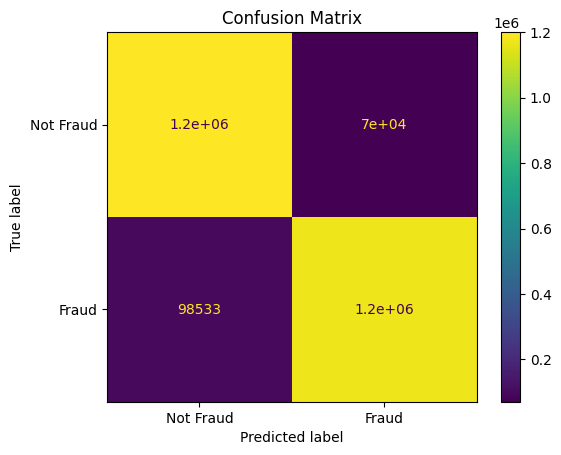

In [5]:
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test, display_labels=["Not Fraud", "Fraud"])
plt.title("Confusion Matrix")
plt.show()

2. ROC Curve

    What It Shows:
    + The tradeoff between the true positive rate (Recall) and false positive rate.
    + AUC (Area Under Curve) quantifies the overall ability of the model to distinguish between classes.

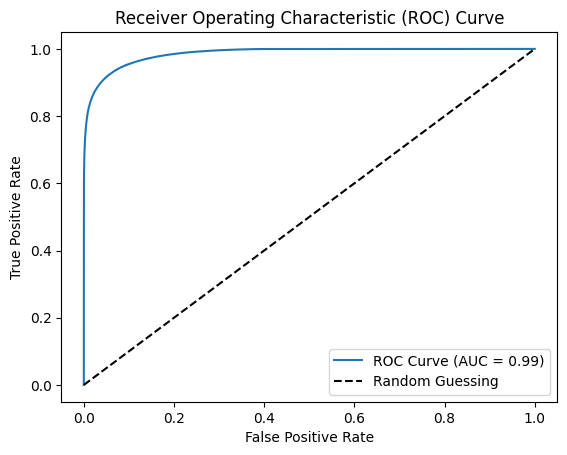

In [6]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.show()

3. Precision-Recall Curve

    What It Shows:
    + The tradeoff between precision and recall at different probability thresholds.
    + Especially useful for imbalanced datasets like fraud detection.

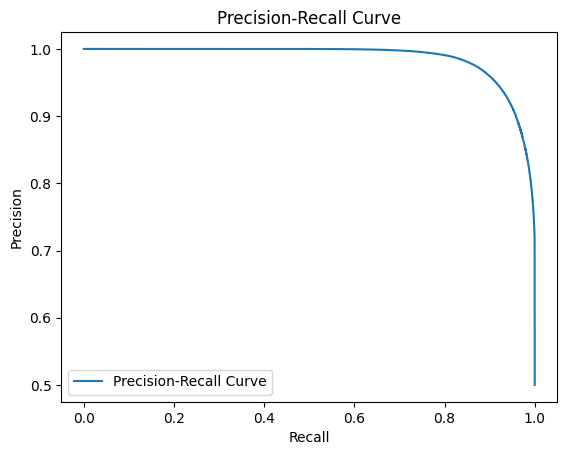

In [7]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(recall, precision, label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


4. Feature Importance Plot

    What It Shows:
    + The relative importance of each feature in the model.
    + Helps interpret the model and identify the most significant predictors.

<Figure size 1000x800 with 0 Axes>

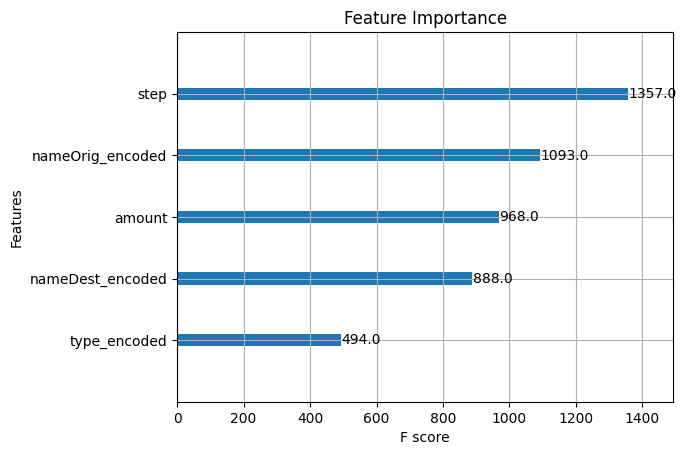

In [8]:
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=10, importance_type="weight")  # Change to 'gain' or 'cover' for other metrics
plt.title("Feature Importance")
plt.show()



5. Calibration Curve

    What It Shows:
    + How well the predicted probabilities align with actual observed probabilities.
    + Useful for evaluating the calibration of probabilistic models.

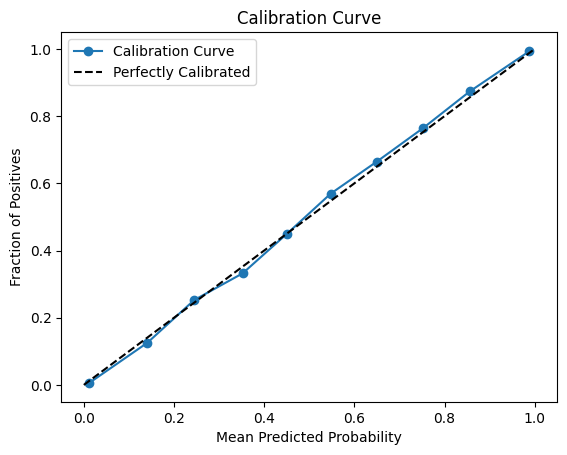

In [9]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker="o", label="Calibration Curve")
plt.plot([0, 1], [0, 1], 'k--', label="Perfectly Calibrated")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.show()


6. Learning Curve

    What It Shows:
    + How model performance changes with varying amounts of training data.
    + Helps identify whether the model suffers from bias or variance issues.

c:\Users\sonia\Desktop\project\.venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:35:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\sonia\Desktop\project\.venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:35:06] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\sonia\Desktop\project\.venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:35:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\User

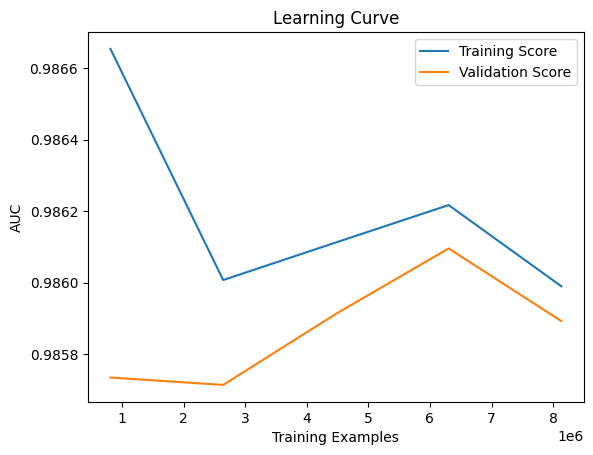

In [10]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(xgb_model, X_train, y_train, cv=5, scoring='roc_auc')

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Score")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation Score")
plt.xlabel("Training Examples")
plt.ylabel("AUC")
plt.title("Learning Curve")
plt.legend()
plt.show()


7. Residual Plot

    What It Shows:
    + The differences between predicted probabilities and actual outcomes.
    + Helps detect systematic errors in predictions.

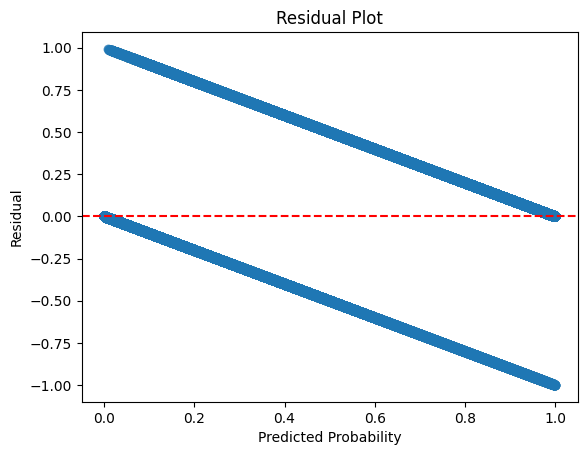

In [11]:
residuals = y_test - y_pred_prob

plt.figure()
plt.scatter(y_pred_prob, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

Visualize a tree

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt

# Plot the first tree (tree index 0)
plt.figure(figsize=(20, 10))
xgb.plot_tree(xgb_model, num_trees=0)  # Use num_trees=0 for the first tree
plt.title("XGBoost Tree Visualization")
plt.show()
